In [6]:
import pandas as pd
import json
import matplotlib.pyplot as plt

In [12]:
data = pd.read_json('output.json')
# print(data)
data["ratingsCount"] = data["ratingsCount"].fillna(0)

In [8]:
data

,isbn,isbn13,title,author,description,imageUrl,publisher,publishDate,numPages,language,reviewsCount,averageRating,ratingsCount,ratingHistogram,crawlSource,genres,series,ebookPrice
0,0976540606,9.780977e+12,"Unauthorized Harry Potter Book Seven News: ""Ha...",W. Frederick Zimmerman,Through the magic of print-on-demand technolog...,https://images-na.ssl-images-amazon.com/images...,Nimble Books,1.114499e+12,152.0,English,1.0,3.89,38,"[0, 6, 8, 8, 16]",https://www.goodreads.com/book/show/9.Unauthor...,NaN,NaN,NaN
1,0345453743,9.780345e+12,The Ultimate Hitchhiker’s Guide to the Galaxy,Douglas Adams,"At last in paperback in one complete volume, h...",https://images-na.ssl-images-amazon.com/images...,Del Rey Books,1.019977e+12,815.0,English,6515.0,4.38,329398,"[3955, 8927, 35330, 90054, 191132]",https://www.goodreads.com/book/show/13.The_Ult...,"[Science Fiction, Fiction, Humor, Fantasy, Cla...",The Hitchhiker’s Guide to the Galaxy,13.99
2,043965548X,9.780440e+12,Harry Potter and the Prisoner of Azkaban,J.K. Rowling,"Harry Potter, along with his best friends, Ron...",https://images-na.ssl-images-amazon.com/images...,Scholastic Inc.,1.083395e+12,435.0,English,90398.0,4.58,4415248,"[25678, 42405, 299962, 1015452, 3031751]",https://www.goodreads.com/book/show/5.Harry_Po...,"[Fantasy, Fiction, Young Adult, Magic, Childre...",Harry Potter,8.99
3,0439682584,9.780440e+12,"Harry Potter Boxed Set, Books 1-5",J.K. Rowling,Box Set containing Harry Potter and the Sorcer...,https://images-na.ssl-images-amazon.com/images...,Scholastic,1.095059e+12,2690.0,English,331.0,4.71,160473,"[2039, 1464, 6088, 21635, 129247]",https://www.goodreads.com/book/show/8.Harry_Po...,"[Fantasy, Young Adult, Fiction, Magic, Adventu...",NaN,NaN
4,0439827604,9.780440e+12,Harry Potter Collection,J.K. Rowling,"Six years of magic, adventure, and mystery mak...",https://images-na.ssl-images-amazon.com/images...,Scholastic,1.126508e+12,3342.0,English,980.0,4.72,33513,"[351, 249, 1200, 4792, 26921]",https://www.goodreads.com/book/show/10.Harry_P...,"[Fantasy, Fiction, Young Adult, Magic, Adventu...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
851,0740745328,9.780741e+12,Millionaire Women Next Door: The Many Journeys...,Thomas J. Stanley,"""Most Americans are not free. They are chained...",https://images-na.ssl-images-amazon.com/images...,Andrews McMeel Publishing,1.083395e+12,320.0,English,78.0,3.88,816,"[19, 65, 208, 223, 301]",https://www.goodreads.com/book/show/1000.Milli...,"[Finance, Nonfiction, Business, Money, Persona...",NaN,2.99
852,0671039830,9.780671e+12,NaN,V.C. Andrews,NaN,NaN,NaN,NaN,NaN,NaN,70.0,3.84,4374,"[84, 361, 1231, 1193, 1505]",https://www.goodreads.com/book/show/226687.Eye...,NaN,Hudson,NaN
853,0671015206,9.780671e+12,NaN,Thomas J. Stanley,NaN,NaN,NaN,NaN,NaN,NaN,4973.0,4.05,122464,"[2168, 7262, 23486, 39519, 50029]",https://www.goodreads.com/book/show/998.The_Mi...,NaN,NaN,NaN
854,0316845469,9.780317e+12,NaN,Alex S. Jones,NaN,NaN,NaN,NaN,NaN,NaN,21.0,4.04,198,"[2, 6, 37, 90, 63]",https://www.goodreads.com/book/show/922617.The...,NaN,NaN,NaN


In [6]:
language_counts = data['language'].value_counts()
print(language_counts)

language
[English]               656
[German]                  3
[Japanese]                1
[French]                  1
[Spanish; Castilian]      1
Name: count, dtype: int64


TypeError: 'value' must be an instance of str or bytes, not a None

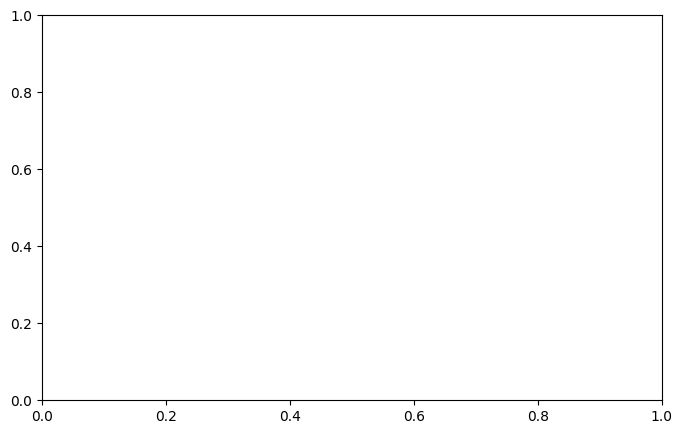

In [13]:
# Tạo biểu đồ đường
# data["ratingsCount"] = data["ratingsCount"].fillna(0)
plt.figure(figsize=(8, 5))
plt.plot(data['isbn'], data['ratingsCount'], marker='o', color='green', label='Ratings Count')

# Thêm tiêu đề và nhãn
plt.title('Ratings Count Trend', fontsize=16)
plt.xlabel('Book Title', fontsize=12)
plt.ylabel('Ratings Count', fontsize=12)
plt.legend()
plt.grid(True)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Hiển thị biểu đồ
plt.show()

In [5]:
import json

# Đường dẫn file JSON
input_file = "data_1_1000.json"  # File gốc
output_file = "output.json"  # File sau khi xử lý

# Hàm xử lý để loại bỏ dấu []
def simplify_json(data):
    simplified = {}
    for key, value in data.items():
        if isinstance(value, list) and len(value) == 1:
            simplified[key] = value[0]  # Lấy giá trị đầu tiên nếu chỉ có 1 phần tử
        else:
            simplified[key] = value  # Giữ nguyên nếu không phải danh sách hoặc có nhiều phần tử
    return simplified

# Đọc dữ liệu từ file JSON
with open(input_file, "r", encoding="utf-8") as file:
    data = json.load(file)

# Xử lý dữ liệu
if isinstance(data, dict):  # Nếu file JSON chứa một object
    simplified_data = simplify_json(data)
elif isinstance(data, list):  # Nếu file JSON chứa một danh sách object
    simplified_data = [simplify_json(item) for item in data]
else:
    raise ValueError("Dữ liệu JSON không hợp lệ, cần là object hoặc danh sách object.")

# Ghi dữ liệu đã xử lý ra file mới
with open(output_file, "w", encoding="utf-8") as file:
    json.dump(simplified_data, file, indent=4, ensure_ascii=False)

print(f"Dữ liệu đã xử lý được lưu vào: {output_file}")


Dữ liệu đã xử lý được lưu vào: output.json
